In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Homework 8: Class review

In this optional homework, each section will cover a key topic from the class. *This is not a comprehensive review*, it will not cover everything on the final exam but it is a good place to start with for your preparation. 

Whatever grade you receive on this assignment will replace your lowest homework or lab grade (assuming it's higher).

### Part 1: Midterm grades and attendance

In this section, you will compare the midterm grades of the students in the 50th percentile of lecture attendance (and above) against the midterm grades in the bottom 50% of attendance. 

The students in the top 50% are considered "attendant".

In [3]:
# Read in the data
midterm = pd.read_csv("./midterm_grades.csv")
midterm.head()

,percent,attendant
0,63.478261,y
1,70.000000,y
2,78.260870,y
3,50.434783,n
4,74.347826,y


#### Question 1.1

Does our data represent a population or a sample? First, make an argument for a population.

**Your response**: The data represents the population for everyone included in this study who attended lecture and took the midterm in the 50th percentile.

#### Question 1.2

Now make an argument for our data as a sample.


**Your response**: The data represents a sample of students who took a midterm and did a lecture which can be compared to the whole population of everyone who attended lecture and did a midterm who is apart of the 50th percentile.

#### Question 1.3

Use `sns.kdeplot` to plot the distributions of those attendance or not. Characterize the distributions and then compare them.

*Note*: This are Kernel Density Estimate plots, which means they are modeling the empirical distributions of the grade. In this case the KDEs make the distributions easier to compare because the otherwise small sample sizes don't give us a neat histogram.


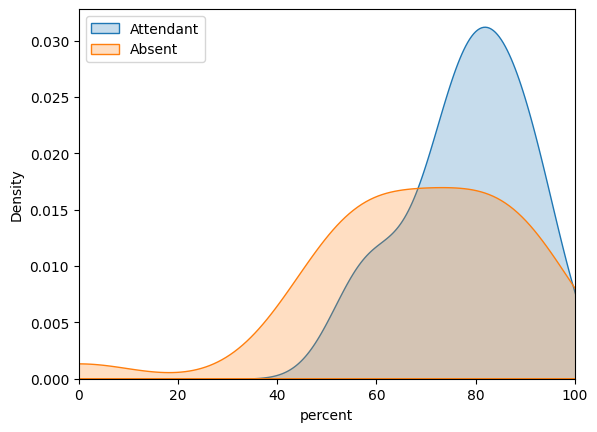

In [4]:
# Plot the distributions
sns.kdeplot(midterm["percent"][midterm["attendant"] == "y"], label = "Attendant", fill = True)
sns.kdeplot(midterm["percent"][midterm["attendant"] == "n"], label = "Absent", fill = True)
plt.xlim(0,100)
plt.legend();

#### Question 1.4 

Based on the distributions, do you notice any outlier grades? Calculate the mean and median for attendant and absent students including the outlier and without the outlier. Explain how excluding the outlier affects the mean and median differently.

In [78]:
# Using IQR to find outliers 
present_scores = midterm.loc[midterm["attendant"] == "y", ["percent"]].sort_values(by = "percent", ascending = True)
absent_scores =midterm.loc[midterm["attendant"] == "n", ["percent"]].sort_values(by = "percent", ascending = True)

print("-------------------------------------------------------------")
mean_attendent = np.mean(present_scores["percent"])
mean_absent = np.mean(absent_scores["percent"])

median_attendent = np.median(present_scores["percent"])
median_absent = np.median(absent_scores["percent"])
print("Mean attendent with outlier", mean_attendent,"%")
print("Median attendent with outlier", median_attendent,"%")
print("---------------------------------------------------------")
print("Mean absent with outlier", mean_absent,"%")
print("Median absent with outlier", median_absent,"%")
print("------------------------------------------------------------")
# Index 1 sorted has a outlier of 0 for the score
absent_wo_outlier = absent_scores.reset_index()[1:]
outlier_absent_dropped_mean = np.mean(absent_wo_outlier["percent"])
outlier_absent_dropped_median = np.median(absent_wo_outlier["percent"])

print(f"Mean absent without outlier: {outlier_absent_dropped_mean}%")
print(f"Median absent without outlier: {outlier_absent_dropped_mean}%")



-------------------------------------------------------------
Mean attendent with outlier 78.20089955034483 %
Median attendent with outlier 80.43478261 %
---------------------------------------------------------
Mean absent with outlier 68.71118012428572 %
Median absent with outlier 70.869565215 %
------------------------------------------------------------
Mean absent without outlier: 71.25603864740741%
Median absent without outlier: 71.25603864740741%


**Your response**: There is one person with the outlier of 0 on the absent test scores. The mean and the median after the dropped value was roughly the same. The mean increased by 3% and the median increased by ~0.5% to ~71.25%
In data sets, an extreme value can pull the mean towards the direction of the tail whereas the median remains relatively unaffected. 


#### Question 1.5

Plot the medians on the previous figure you made using `plt.axvline`. Because there is a left skew in both distributions, the median will be a better description of typical exam performance than the mean.

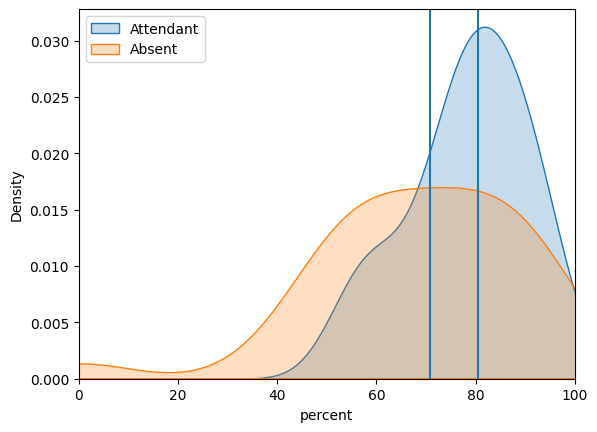

In [80]:
plt.axvline(median_attendent)

plt.axvline(median_absent)

sns.kdeplot(midterm["percent"][midterm["attendant"] == "y"], label = "Attendant", fill = True)
sns.kdeplot(midterm["percent"][midterm["attendant"] == "n"], label = "Absent", fill = True)
plt.xlim(0,100)
plt.legend();


#### Question 1.6

If we conceptualize performance on the midterm in the class as a sample of a virtual population of students that show up and those that don't, then we acknowledge that this observed difference could have happend by chance. We therefore need to do statistics.

If we're wondering whether there is truly a difference in grades between the two groups, what is a possible Null and Alternative Hypothesis?

**Null Hypothesis**: There is no difference in the average scores between students who attend and don't attend class. H0 : mean = 68%

**Alternative Hypothesis**: There is a difference in the average scores between students who attend and don't attend class. Ha : mean != 68%

#### Question 1.7

Create a 95% confidence interval around either the mean or median of midterm grades among students that are typically present by bootstrapping. Based on the interval and the statistic observed for students not typically present, do you reject or fail to reject the null?

Interval(2.5): 74.01402691545952
Interval(97.5): 82.3927133654415
Absent Score: 68.71118012428572


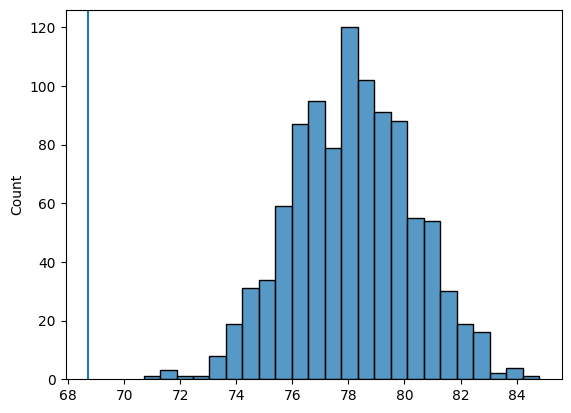

In [68]:
mean_present= []

for i in range(1000):
    resampled_mean = midterm.sample(frac = 1, replace = True)
    present = np.mean(resampled_mean["percent"][resampled_mean["attendant"] == "y"])

    mean_present = np.append(mean_present, present)
sns.histplot(mean_present)
print("Interval(2.5):", np.percentile(mean_present, 2.5))
print("Interval(97.5):", np.percentile(mean_present, 97.5))
print("Absent Score:", mean_absent)

plt.axvline(mean_absent)

In [81]:
# Answer either True or False
reject_null = True
# The absent score is not within the 95% confidence interval therefore we reject the null hypothesis that there is no difference in scores.

### Part 2: Simple and Multiple Linear Regression

In this section we'll fit simple and multiple linear models to try and predict car insurance premiums

In [ ]:
insurance = pd.read_csv("car_insurance_premium_dataset.csv")
insurance.head()

,Driver Age,Driver Experience,Previous Accidents,Annual Mileage (x1000 km),Car Manufacturing Year,Car Age,Insurance Premium
0,56,32,4,17,2002,23,488.35
1,46,19,0,21,2025,0,486.15
2,32,11,4,15,2020,5,497.55
3,60,0,4,19,1991,34,498.35
4,25,7,0,13,2005,20,495.55


#### Question 2.1 

Calculate the correlation coefficient between Driver Age and Insurance Premium. Do this manually; don't use any `numpy` functions.

How do you interpret the correlation? Be sure to evaluate the key assumption of correlation. 

In [ ]:
age = insurance["Driver Age"]
premium = insurance["Insurance Premium"]

age_avg = np.mean(insurance["Driver Age"])
premium_avg = np.mean(insurance["Insurance Premium"])

r = np.mean(((age - age_avg)/np.std(age)) * ((premium - premium_avg)/np.std(premium)))

r

-0.7768483315311162

**Your response:** There is a strong negative correlation between driver age(x) and insurance premium(y). As driver age goes up by one, insurance premium will decrease. 

Check assumptions for outliersand approximent linearity.

<Axes: xlabel='Driver Age', ylabel='Insurance Premium'>

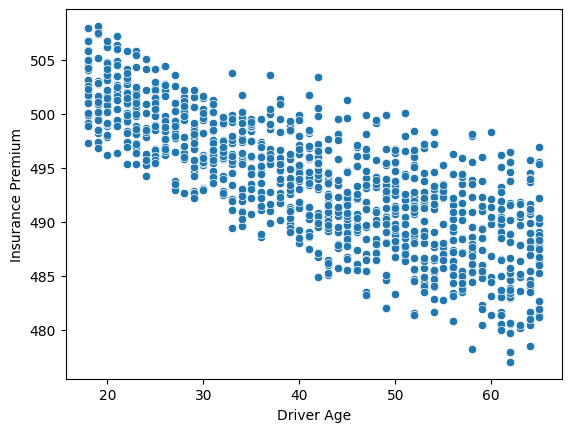

In [ ]:
# Assumption check
age_table = insurance["Driver Age"]
premium_table = insurance["Insurance Premium"]
sns.scatterplot(x = age_table, y = premium_table)

#### Question 2.2

Now calculate the line of best fit between insurance premium (x) and driver age (y). Then plot a scatterplot of the association, along with the line of best fit.

<Axes: xlabel='Driver Age', ylabel='Insurance Premium'>

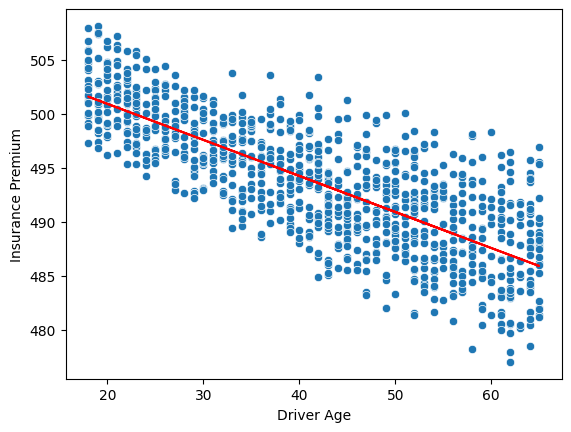

In [ ]:
slope = r * (np.std(premium) / np.std(age))
intercept = np.mean(premium) - slope * np.mean(age)
equation = slope * age + intercept
plt.plot(insurance["Driver Age"], slope * age + intercept, color = "red")

sns.scatterplot(x = age_table, y = premium_table)

#### Question 2.3

Evaluate the core three assumptions of simple linear regression:

**1)** Normally distributed response variable

**2)** Linear association between predictor and response

**3)** Homoscedastic residuals

Show your work

(rmse): 13.833920422378643
y = -0.33350572985965066x + 507.607750718915


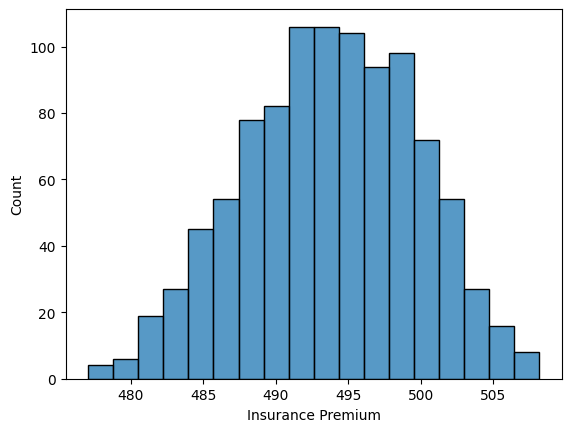

In [ ]:
# Any code you might need
sns.histplot(insurance["Insurance Premium"])

prediction_premium = slope * age + intercept
errors = premium - prediction_premium
rmse = np.mean(errors**2)
print("(rmse):", rmse)
print(f"y = {slope}x + {intercept}")

**Your response**: 
1. The response variable (y) is normally distributed as seen in the histogram defined by the bell curved shape.

2. In the scatterplot with the regression line, we can see a negative association with age and insurance premium. As age increases, the insurance premium will decrease (We are predicting car insurance premium).
In the linear regression equation for the scatterplot, we have a slope of -0.33 and a intercept of 507.60 (dollars) . This tells us that the average starting insurance premium is at 507 (dollars) and decreases by 0.33 (dollars) as the drivers get older.

4. The scatterplot has even spread along the entire linear regression line. This shows us that there is equal variance across the range of the model.
The rmse calculated tells us how far on average are the predictions from the actual values. I calculated the rmse of 13.83 which tells us that on average my predictions are off by about 13.83 (dollars).



#### Question 2.4

Split your data into train and test sets with a test size of 25%.Then fit 5 models on your training data. The first should have a single predictor, driver age, and each subsequent model should add another predictor (so 1, 2, 3, 4 and 5 predictors). Calculate the test RMSE on each model.

In [82]:
insurance.head(5)

NameError: name 'insurance' is not defined

In [83]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

target = insurance["Insurance Premium"]   # Initialize the target
features = [insurance[["Driver Age"]],  # create a list of feature combinations to loop through
            insurance[["Driver Age", "Driver Experience"]], 
            insurance[["Driver Age", "Driver Experience", "Previous Accidents"]], 
            insurance[["Driver Age", "Driver Experience", "Previous Accidents", "Annual Mileage (x1000 km)"]],
            insurance[["Driver Age", "Driver Experience", "Previous Accidents", "Annual Mileage (x1000 km)", "Car Manufacturing Year"]]]

features_rmse = np.empty(0) # initalize empty list to hold rmse
for i in features: # loop through each item in the features 
    X_train, X_test, y_train, y_test = train_test_split(i, target, test_size = 0.25)
    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    rmse = np.sqrt(np.mean((y_test - pred) ** 2)) # calculate rmse
   
    features_rmse = np.append(features_rmse, rmse) #  append the rmse

for i in range(1,6):
    print(f"{i} feature rmse: {features_rmse[i - 1]}") 

ModuleNotFoundError: No module named 'sklearn'

#### Question 2.5

How does RMSE change with added predictors? Which other predictors significantly improve the fit of the model, and is there any point at which the model fit gets worse on the test data? There can multiple answers to these questions depending on your predictors and your random split of data.

**Your response**: As the number of predictors increase, the rmse decreases to a certain extent. Classifications with 1 and 2 variables produced the highest errors of ~3.7 and ~2.7.

Combination 3 of ["Driver Age", "Driver Experience", "Previous Accidents"] produced the best results with the rmse of ~1.0# and adding ["Annual Mileage (x1000 km)"] did not seem to make any significant impacts. It was after adding the "Car Manufacturing Year" that increased the error back to ~2.6. 



### Part 3: Classification

Let's end by doing some classification and comparing decision boundaries. Below we read in some data about cell phones, they're various characteristics, an their price range.

In [ ]:
mobile = pd.read_csv("mobile_phones.csv")
mobile.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


#### Question 3.1

Determine how many observations for each price range we have. Then plot a scatterplot of "batter power" and "ram". Change the color of the points by price range.

In [ ]:
counts_category = mobile.groupby("price_range")["price_range"].count()
counts_category 

price_range
0    500
1    500
2    500
3    500
Name: price_range, dtype: int64

Text(0, 0.5, 'ram')

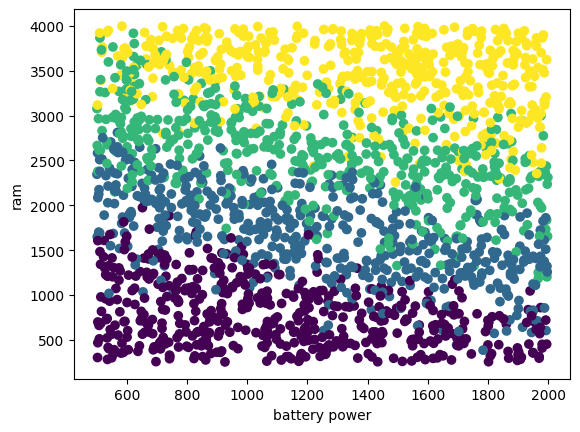

In [ ]:
plt.scatter(mobile["battery_power"], mobile["ram"], c = mobile["price_range"])
plt.xlabel("battery power")
plt.ylabel("ram")
    

#### Question 3.2

Do you expect this to be a relatively easy or challenging classification problem? Explain your answer in the context of the figure you just made.

**Your response**: I would say that this is a somewhat difficult classfication. There are patches were the colors do not overlap but once they intersect there the clustering are mixed. There is not a clear definitive line between each price range. 

#### Question 3.3

You will now split your data into train and test sets and fit three different classifies to the training sets: KNN (use a K of 7), Decision Tree, and Naive Bayes classified ("GaussianNB").

After fitting each classifier, create test predictions and quantify the accuracy of each.

Finally, I've provided code to plot the resulting decision boundaries.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import DecisionBoundaryDisplay


In [ ]:
def global_data_split(): # split the data as a global variable so train_test_split is consistent
    global X_train, X_test, y_train, y_test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

# Initializing Variables
global_data_split() # call global train_test variables

X = mobile[["battery_power", "ram"]]
y = mobile["price_range"]

clf = KNeighborsClassifier(n_neighbors = 7)
clf.fit(X_train, y_train)
clf.predict(X_test)

X_test["predict"] = np.array(clf.predict(X_test))
X_test["actual"] = y_test
X_test["result"] = X_test["predict"] == X_test["actual"]

accuracy_k = np.sum(X_test["result"])/len(X_test)
accuracy_k 

0.806

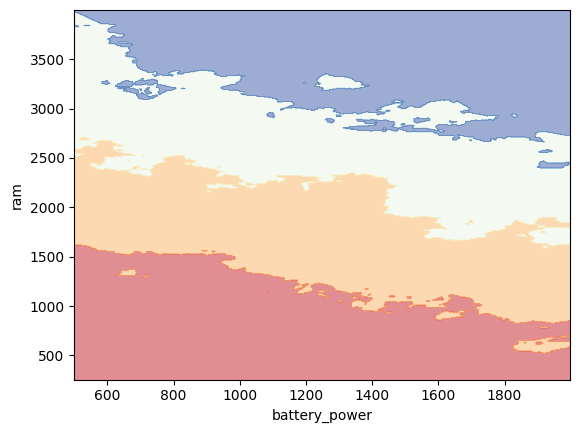

In [ ]:
DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        alpha = 0.5,
        grid_resolution= 500)

In [ ]:
# Naive Bayes
GaussianNB
clf = GaussianNB()
global_data_split()  # call global train_test variables
clf.fit(X_train, y_train)
clf.predict(X_test)

X_test["predict"] = np.array(clf.predict(X_test))
X_test["actual"] = y_test
X_test["result"] = X_test["predict"] == X_test["actual"]

accuracy_g = np.sum(X_test["result"])/len(X_test)
accuracy_g


0.754

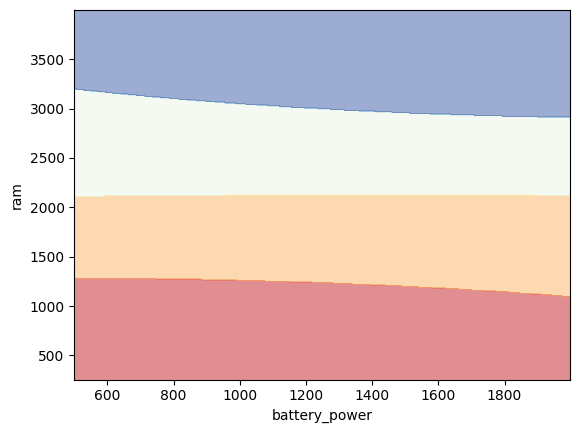

In [ ]:
DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        alpha = 0.5,
        grid_resolution= 500)

In [ ]:
# Decision tree

DecisionTreeClassifier
clf = DecisionTreeClassifier()

global_data_split()  # call global train_test variables
clf.fit(X_train, y_train)

clf.predict(X_test)

X_test["predict"] = np.array(clf.predict(X_test))
X_test["actual"] = y_test
X_test["result"] = X_test["predict"] == X_test["actual"]

accuracy_t = np.sum(X_test["result"])/len(X_test)
accuracy_t

0.758

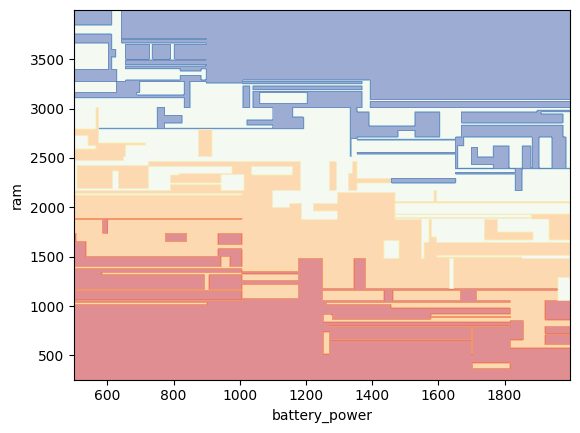

In [ ]:
DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        alpha = 0.5,
        grid_resolution= 500)


#### Question 3.4

Which classifier had the highest accuracy? Why do you think it did better than the others, given the decision boundaries displayed for each model?

In [ ]:
print("K-neighbors", accuracy_k)
print("Boundries:", accuracy_g)
print("Trees:", accuracy_t)

K-neighbors 0.806
Boundries: 0.754
Trees: 0.758


**Your response**: The K_Neighbors classifier had the greatest accuracy compared to the boundires or trees classifiers. Looking at the distribution for the price ranges, the trees have rigid borders that specify the areas of overlap. When looking at the scatterplot, areas with both colors are defined as one in the tree method whereas the k_neighbors uses the generalized area. If there were more colors in one area with overlap of the others, the tree method can easily classify the wrong points. K neighbors calculated  with the most colors in a certain cluster which allowed for approximent generalization. 

The Gaussian and the Trees method had very similar accuracy scores. Gaussian has a smoother generalization of the distribution without showing the details of overlap. The trees method uses more overlap in areas where one color dominates. 

Over classifiying (?) the areas seems to increase errors as much as smoothing everything over. 

That's a wrap on the homework! We'll go over it during the Week 10 review. Be sure to submit to the appropriate assignment on Canvas.